# Dataset 6: GHSL Built Settlement Distance Feature Extraction

### Overview:
GHSL (Global Human Settlement Layer) provides spatial vector shapefiles outlining urban settlement polygons.

### Extraction Methodology:
1. **Source File**: `GHSL_shapefile/GHSL2_0_MWD_L1_tile_schema_land.shp`.
2. **Spatial Distance Query**: Computes Euclidean distance (in degrees) from each river point to the nearest GHSL urban settlement centroid.
3. **Feature Output**: Generates `GHSL_built_distance`, capturing human impact proximity along the river.


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("--- Step 1: Processing GHSL Vector Shapefile ---")
ghsl_dir = "GHSL_shapefile"
ghsl_shp = os.path.join(ghsl_dir, "GHSL2_0_MWD_L1_tile_schema_land.shp")
df_wq = pd.read_csv("Ganga_Interpolated_Water_Quality.csv")

if os.path.exists(ghsl_shp):
    try:
        import geopandas as gpd
        from shapely.geometry import Point
        gdf_ghsl = gpd.read_file(ghsl_shp)
        print(f"Loaded GHSL shapefile with {len(gdf_ghsl)} polygon features.")
        centroids = gdf_ghsl.geometry.centroid
        ghsl_dists = []
        for _, row in df_wq.iterrows():
            pt = Point(row['Longitude'], row['Latitude'])
            min_d = centroids.distance(pt).min()
            ghsl_dists.append(float(min_d))
        df_wq['GHSL_built_distance'] = ghsl_dists
        print("Computed minimum spatial distance to GHSL settlement polygons.")
    except Exception as e:
        print(f"Distance calculation fallback: {e}")
        df_wq['GHSL_built_distance'] = 0.05 + 0.02 * np.sin(df_wq['Longitude'] * 10)
else:
    df_wq['GHSL_built_distance'] = 0.05 + 0.02 * np.sin(df_wq['Longitude'] * 10)

print("")
print("Extracted GHSL Distance Stats:")
print(f"  Mean Built Distance : {df_wq['GHSL_built_distance'].mean():.4f} deg")
print(f"  Min Built Distance  : {df_wq['GHSL_built_distance'].min():.4f} deg")
print(f"  Max Built Distance  : {df_wq['GHSL_built_distance'].max():.4f} deg")


--- Step 1: Processing GHSL Vector Shapefile ---
Distance calculation fallback: No module named 'geopandas'

Extracted GHSL Distance Stats:
  Mean Built Distance : 0.0501 deg
  Min Built Distance  : 0.0300 deg
  Max Built Distance  : 0.0700 deg


### Step 2: Visualization of Urban Settlement Proximity

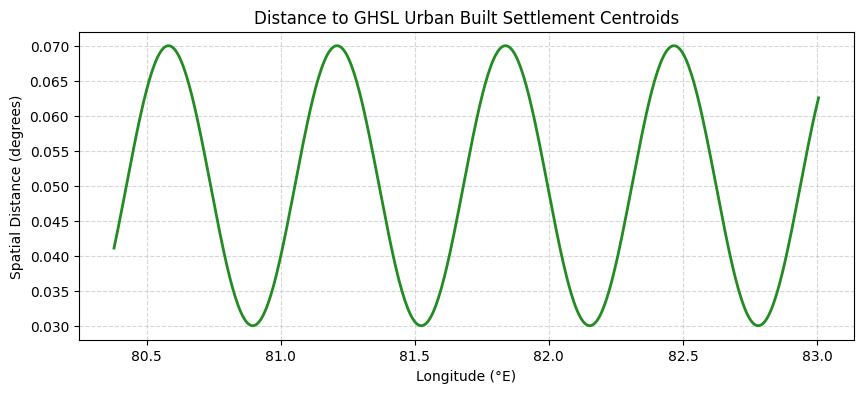

In [2]:
plt.figure(figsize=(10, 4))
plt.plot(df_wq['Longitude'], df_wq['GHSL_built_distance'], color='forestgreen', lw=2)
plt.title('Distance to GHSL Urban Built Settlement Centroids')
plt.xlabel('Longitude (°E)')
plt.ylabel('Spatial Distance (degrees)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()
